# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Woman's Clothing E-Commerce Dataset](https://www.kaggle.com/datasets/razanihababdellatif/womens-e-commerce-clothing-reviews-and-sales)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

/kaggle/input/datasets/razanihababdellatif/womens-e-commerce-clothing-reviews-and-sales/women_clothing_50k.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('women_clothing_50k.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,product_id,category,subcategory,material,color,size,season,style,price_usd,discount_percent,rating,review_count,stock_quantity,units_sold,return_rate
0,WC000001,Jeans,Skinny Jeans,Denim,Red,M,Summer,Business Casual,37.00,0,0.0,0,2,14,0.17
1,WC000002,Dresses,Wrap Dress,Cotton,White,M,Winter,Casual,59.12,10,0.0,0,13,31,0.13
2,WC000003,T-Shirts,V-Neck T-Shirt,Cotton,Purple,M,All Season,Casual,27.65,0,0.0,0,10,2,0.11
3,WC000004,Sweaters,Oversized Sweater,Wool,Brown,S,Winter,Formal,72.64,0,2.9,17,104,292,0.14
4,WC000005,Sweaters,Oversized Sweater,Wool,White,M,Winter,Minimalist,72.61,40,0.0,0,12,15,0.07


## last Five row

In [4]:
df.tail()

,product_id,category,subcategory,material,color,size,season,style,price_usd,discount_percent,rating,review_count,stock_quantity,units_sold,return_rate
49995,WC049996,Coats,Long Coat,Cotton,Black,L,Winter,Business Casual,67.13,10,3.7,1,54,23,0.12
49996,WC049997,Dresses,Midi Dress,Cotton Blend,White,M,Spring,Bohemian,81.27,20,4.3,2,154,52,0.14
49997,WC049998,Jeans,Wide-Leg Jeans,Cotton Blend,Red,L,Autumn,Minimalist,60.96,20,5.0,1,12,84,0.16
49998,WC049999,Sweaters,Knit Sweater,Wool,Beige,L,Autumn,Bohemian,79.54,20,4.4,2,4,140,0.08
49999,WC050000,Tops,Long Sleeve Top,Viscose,White,M,Winter,Elegant,19.72,0,0.0,0,29,6,0.06


## Shape of our dataset

In [5]:
df.shape

(50000, 15)

## List out all columns

In [6]:
df.columns

Index(['product_id', 'category', 'subcategory', 'material', 'color', 'size',
       'season', 'style', 'price_usd', 'discount_percent', 'rating',
       'review_count', 'stock_quantity', 'units_sold', 'return_rate'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

product_id           object
category             object
subcategory          object
material             object
color                object
size                 object
season               object
style                object
price_usd           float64
discount_percent      int64
rating              float64
review_count          int64
stock_quantity        int64
units_sold            int64
return_rate         float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_id        50000 non-null  object 
 1   category          50000 non-null  object 
 2   subcategory       50000 non-null  object 
 3   material          50000 non-null  object 
 4   color             50000 non-null  object 
 5   size              50000 non-null  object 
 6   season            50000 non-null  object 
 7   style             50000 non-null  object 
 8   price_usd         50000 non-null  float64
 9   discount_percent  50000 non-null  int64  
 10  rating            50000 non-null  float64
 11  review_count      50000 non-null  int64  
 12  stock_quantity    50000 non-null  int64  
 13  units_sold        50000 non-null  int64  
 14  return_rate       50000 non-null  float64
dtypes: float64(3), int64(4), object(8)
memory usage: 5.7+ MB


## Check Null Value

In [9]:
df.isnull().sum()

product_id          0
category            0
subcategory         0
material            0
color               0
size                0
season              0
style               0
price_usd           0
discount_percent    0
rating              0
review_count        0
stock_quantity      0
units_sold          0
return_rate         0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,price_usd,discount_percent,rating,review_count,stock_quantity,units_sold,return_rate
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,61.858053,9.617800,3.056088,9.767320,37.515080,185.190660,0.107761
std,36.067137,12.369801,1.905743,32.783376,39.945939,530.180836,0.031606
min,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34.890000,0.000000,0.000000,0.000000,9.000000,21.000000,0.080000
50%,53.750000,0.000000,3.900000,2.000000,25.000000,59.000000,0.110000
75%,80.030000,15.000000,4.400000,8.000000,53.000000,163.000000,0.130000
max,275.560000,50.000000,5.000000,1639.000000,531.000000,31215.000000,0.230000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

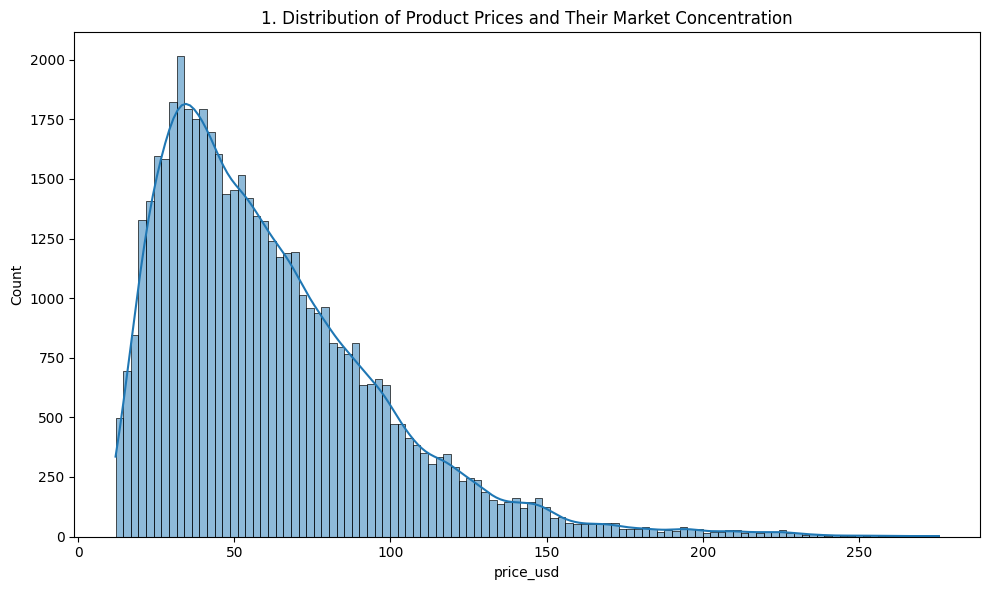

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='price_usd', kde=True)
plt.title(f'{plot_no}. Distribution of Product Prices and Their Market Concentration')
show_fig()
plot_no += 1

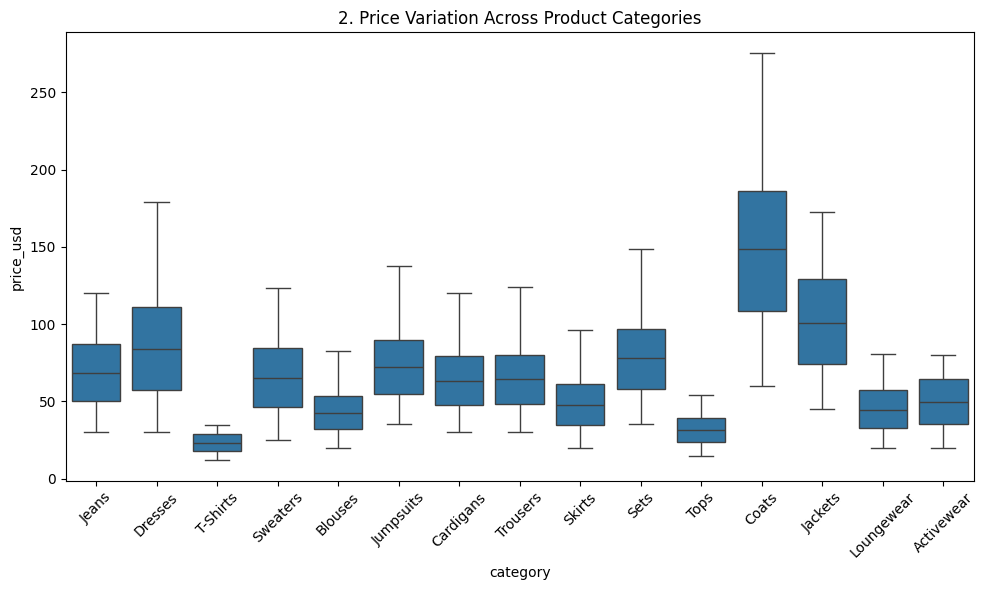

In [14]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='category', y='price_usd')
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Price Variation Across Product Categories')
show_fig()
plot_no += 1

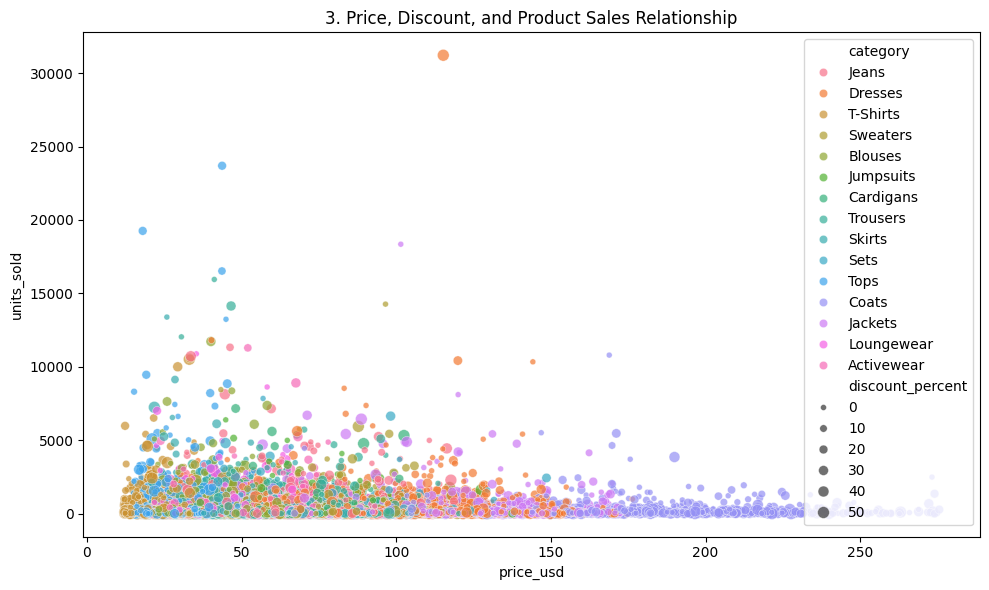

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='price_usd', y='units_sold', hue='category', size='discount_percent', alpha=0.7)
plt.title(f'{plot_no}. Price, Discount, and Product Sales Relationship')
show_fig()
plot_no += 1

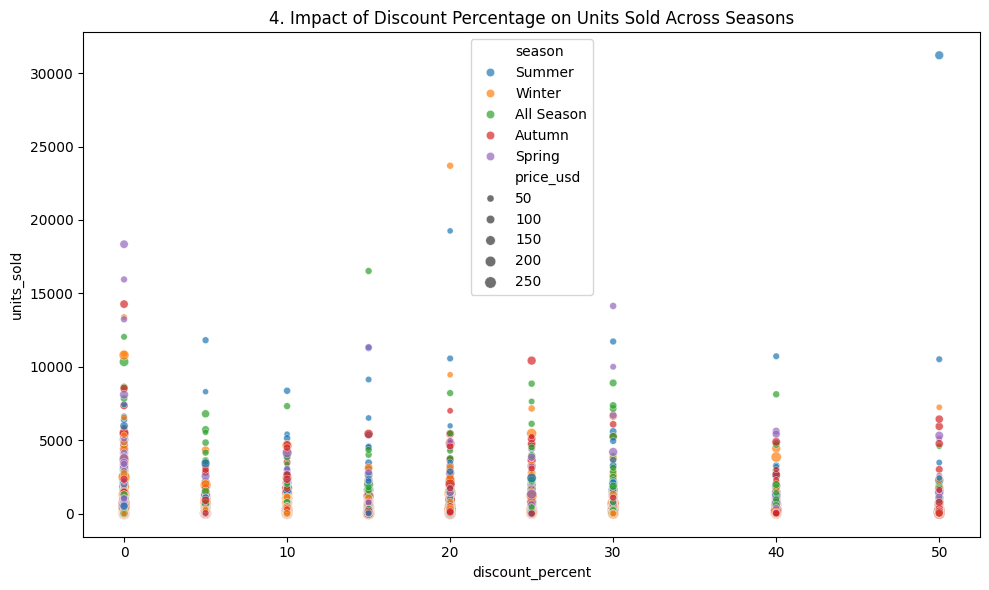

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='discount_percent', y='units_sold', hue='season', size='price_usd', alpha=0.7)
plt.title(f'{plot_no}. Impact of Discount Percentage on Units Sold Across Seasons')
show_fig()
plot_no += 1

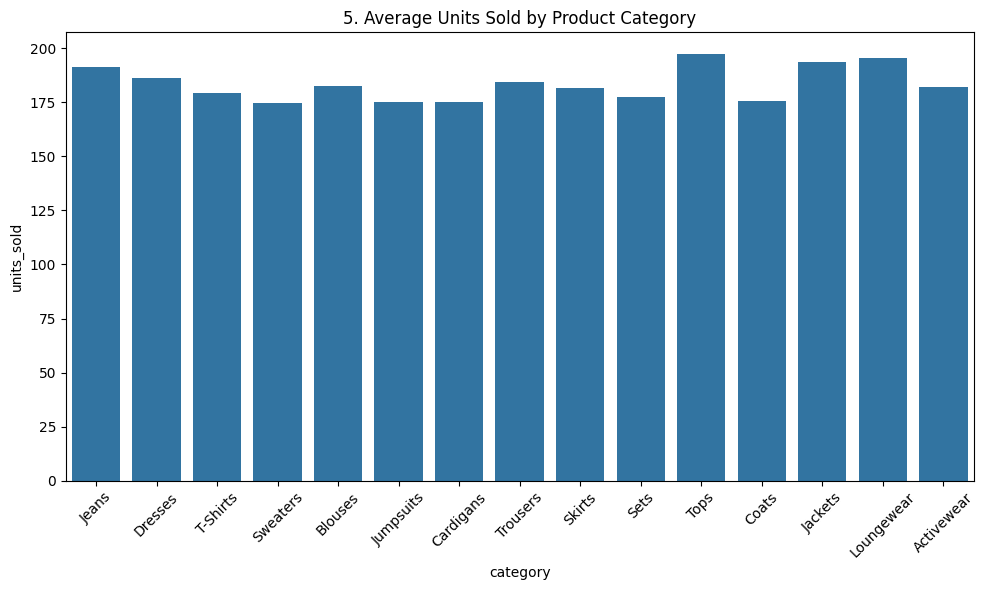

In [17]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='category', y='units_sold', estimator='mean', errorbar=None)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Average Units Sold by Product Category')
show_fig()
plot_no += 1

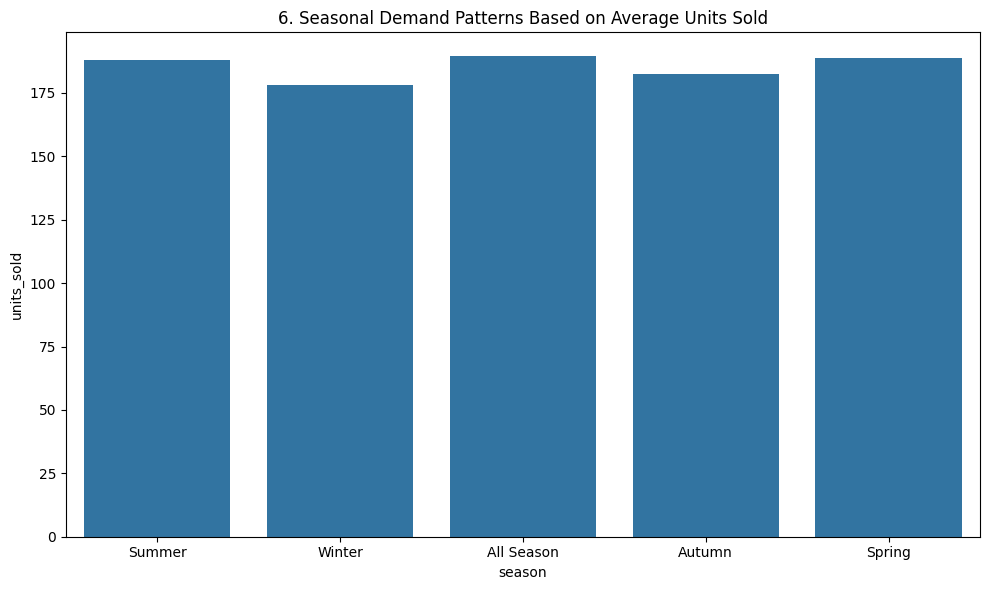

In [18]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='season', y='units_sold', estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Seasonal Demand Patterns Based on Average Units Sold')
show_fig()
plot_no += 1

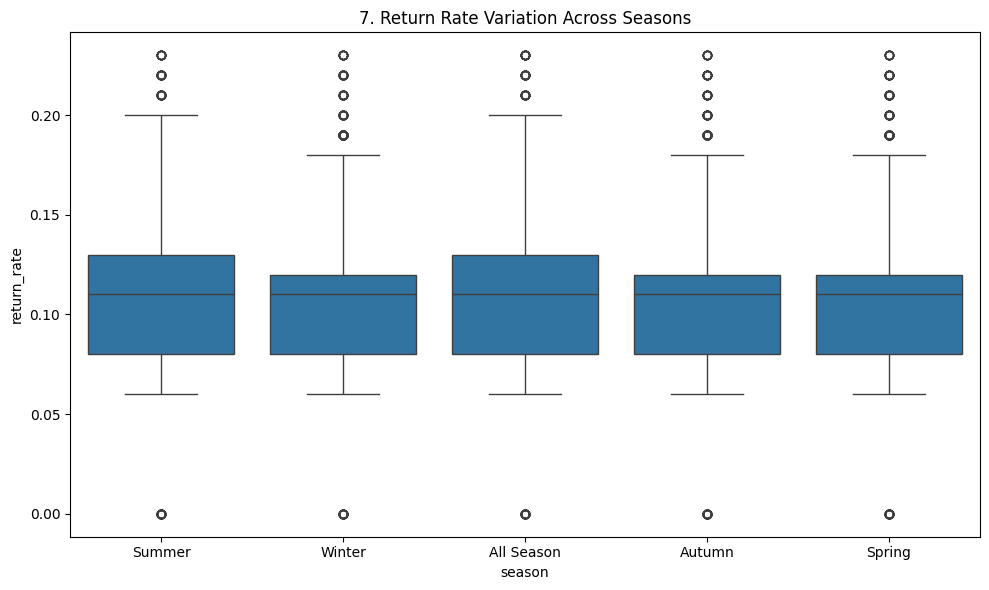

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='season', y='return_rate')
plt.title(f'{plot_no}. Return Rate Variation Across Seasons')
show_fig()
plot_no += 1

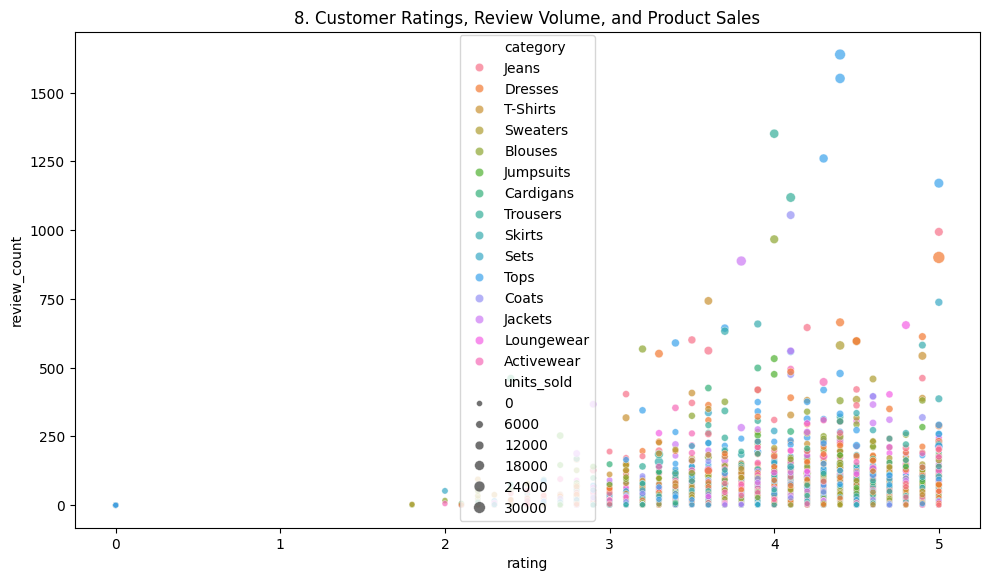

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='rating', y='review_count', hue='category', size='units_sold', alpha=0.7)
plt.title(f'{plot_no}. Customer Ratings, Review Volume, and Product Sales')
show_fig()
plot_no += 1

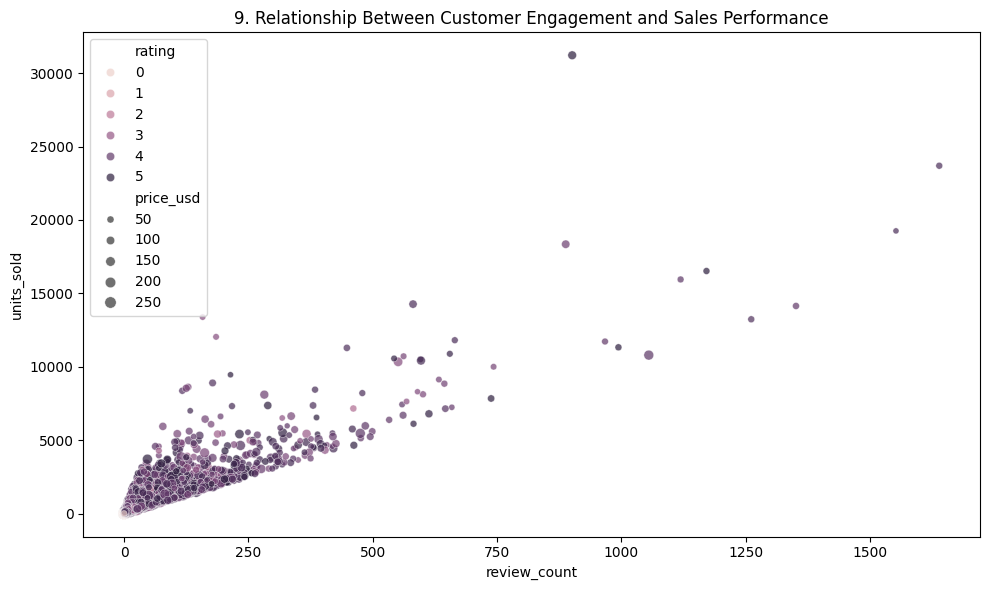

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='review_count', y='units_sold', hue='rating', size='price_usd', alpha=0.7)
plt.title(f'{plot_no}. Relationship Between Customer Engagement and Sales Performance')
show_fig()
plot_no += 1

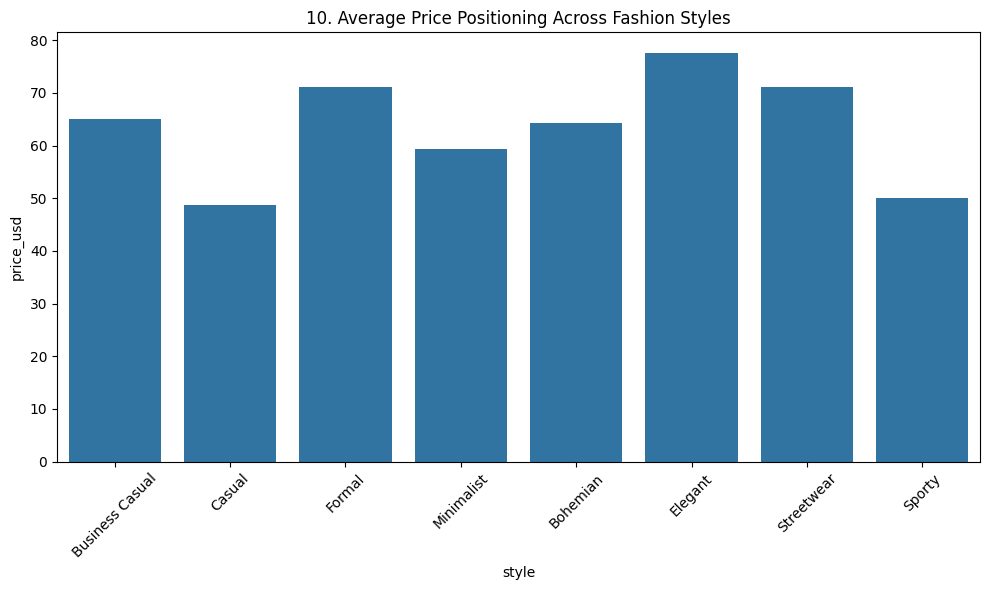

In [22]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='style', y='price_usd', estimator='mean', errorbar=None)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Average Price Positioning Across Fashion Styles')
show_fig()
plot_no += 1

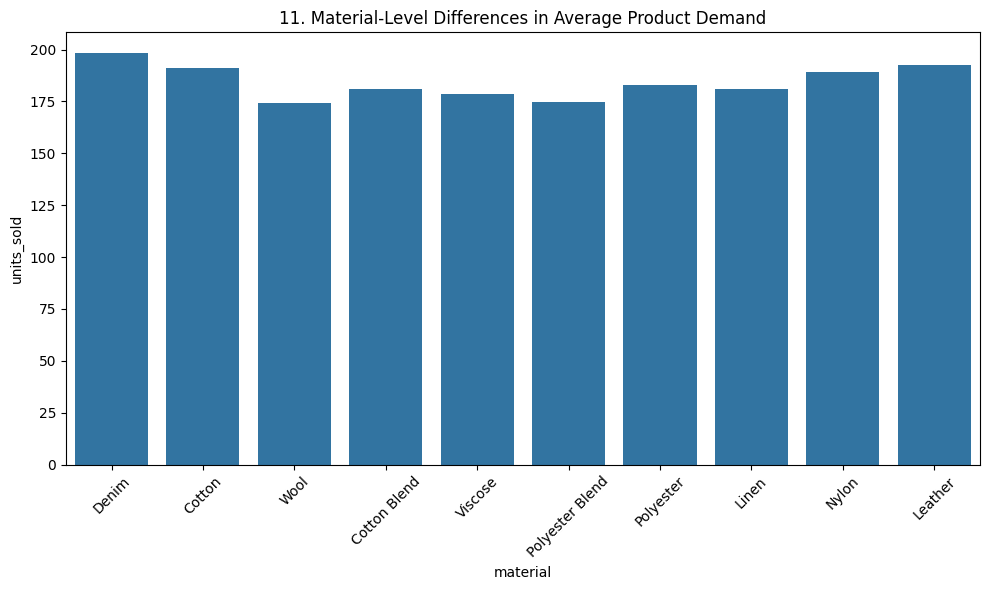

In [23]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='material', y='units_sold', estimator='mean', errorbar=None)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Material-Level Differences in Average Product Demand')
show_fig()
plot_no += 1

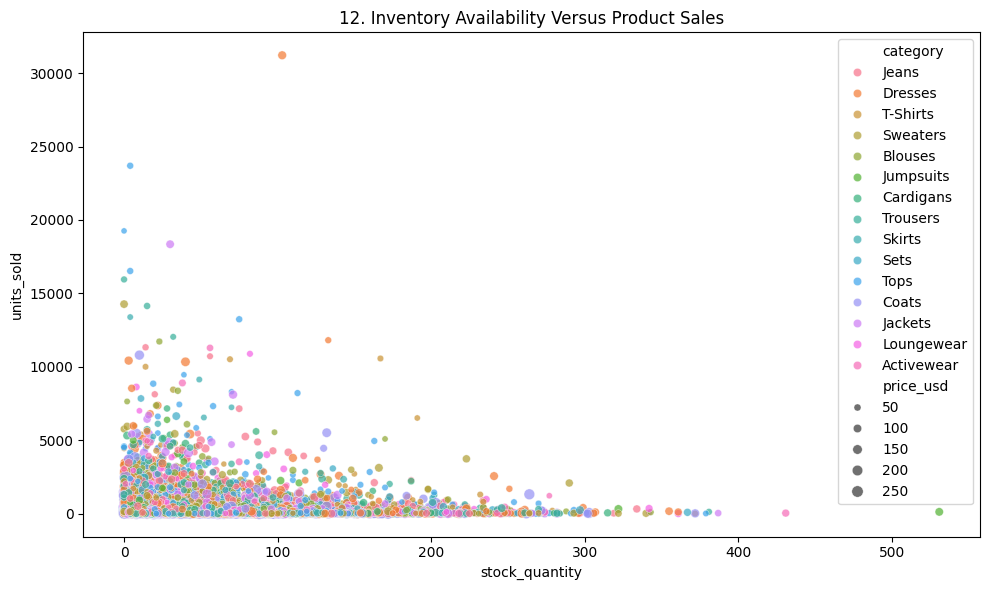

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='stock_quantity', y='units_sold', hue='category', size='price_usd', alpha=0.7)
plt.title(f'{plot_no}. Inventory Availability Versus Product Sales')
show_fig()
plot_no += 1

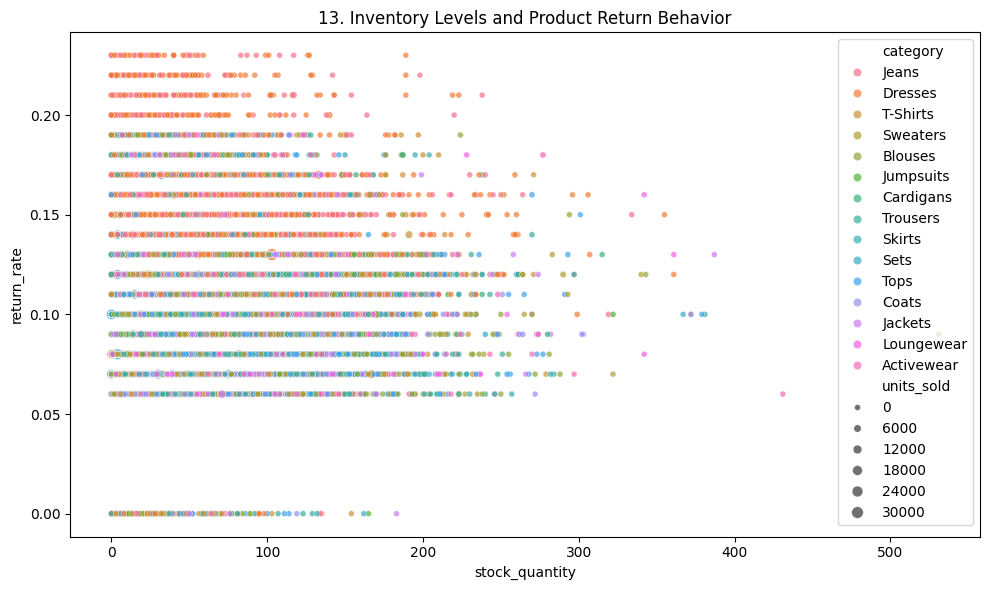

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='stock_quantity', y='return_rate', hue='category', size='units_sold', alpha=0.7)
plt.title(f'{plot_no}. Inventory Levels and Product Return Behavior')
show_fig()
plot_no += 1

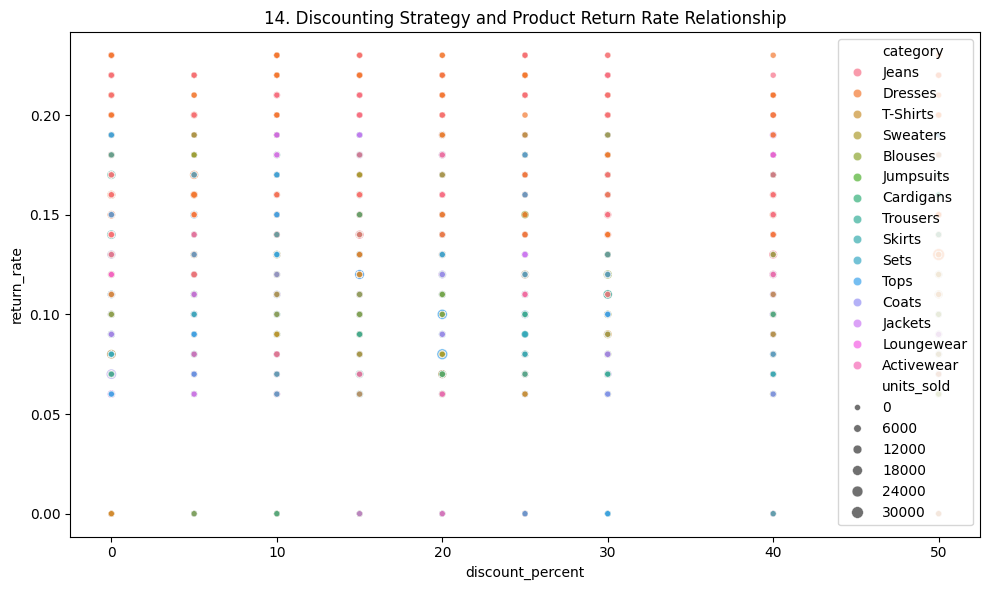

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='discount_percent', y='return_rate', hue='category', size='units_sold', alpha=0.7)
plt.title(f'{plot_no}. Discounting Strategy and Product Return Rate Relationship')
show_fig()
plot_no += 1

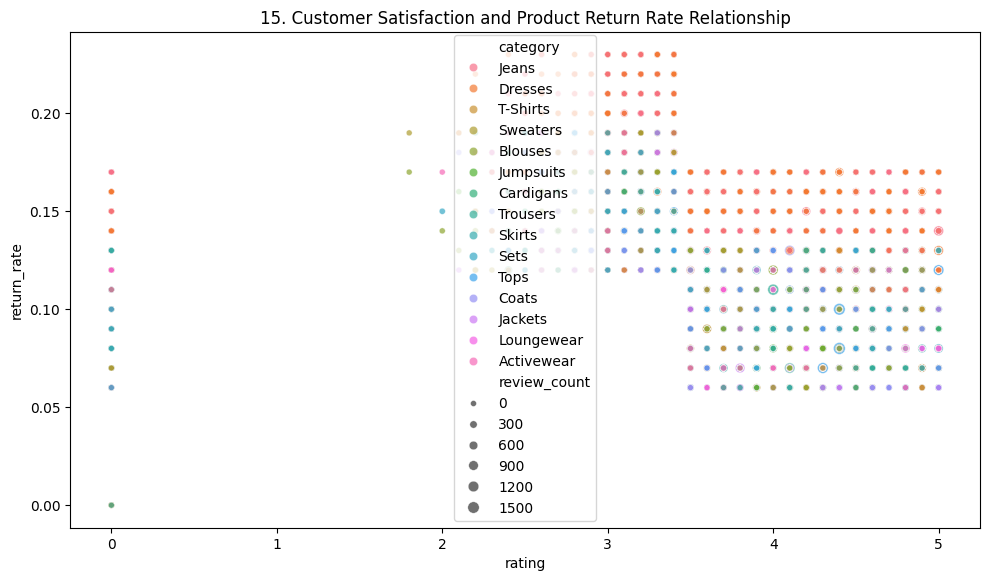

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='rating', y='return_rate', hue='category', size='review_count', alpha=0.7)
plt.title(f'{plot_no}. Customer Satisfaction and Product Return Rate Relationship')
show_fig()
plot_no += 1

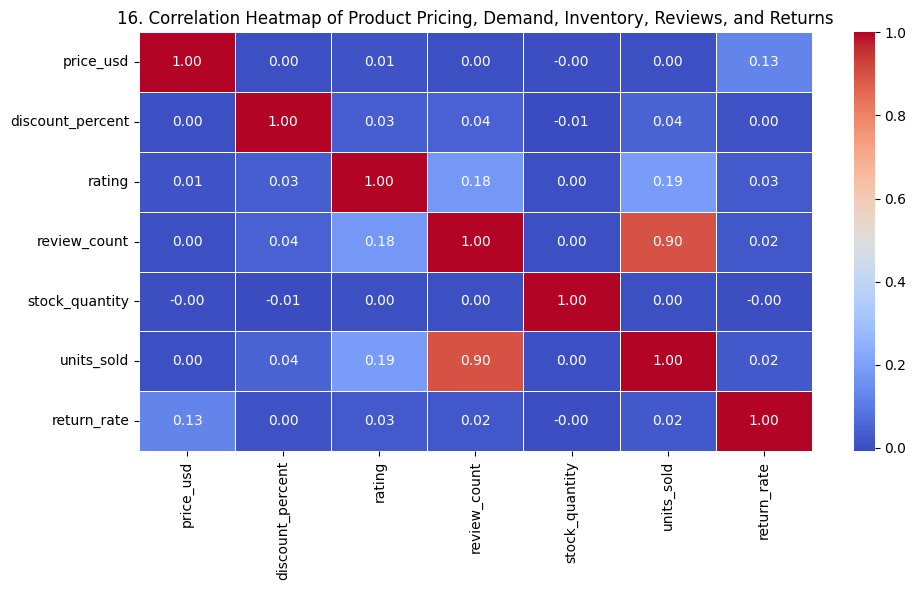

In [28]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(f'{plot_no}. Correlation Heatmap of Product Pricing, Demand, Inventory, Reviews, and Returns')
show_fig()
plot_no += 1

# Model Training

## Select target and features

In [29]:
X = df.drop(columns=['units_sold'])
y = df['units_sold']

## Separate numerical and categorical columns

In [30]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

## Build preprocessing pipeline

In [31]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols)
    ]
)

## Split the dataset

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train Gradient Boosting Regression model

In [33]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['price_usd', 'discount_percent', 'rating', 'review_count',
       'stock_quantity', 'return_rate'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['product_id', 'category', 'subcategory', 'material', 'color', 'size',
       'season', 'style'],
      dtype='object'))])),
                ('regressor',
                 GradientBoostingRegressor(learning_rate=0.05, max_depth=4,
                                           n_estimators=200,
                                           random_state=42))])

## Make predictions

In [34]:
y_pred = model.predict(X_test)

## Print model performance

In [35]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Model Accuracy Score: {r2 * 100:.2f}%")

R² Score: 0.7686
MAE: 75.1693
RMSE: 284.9833
Model Accuracy Score: 76.86%


## Plot actual versus predicted values

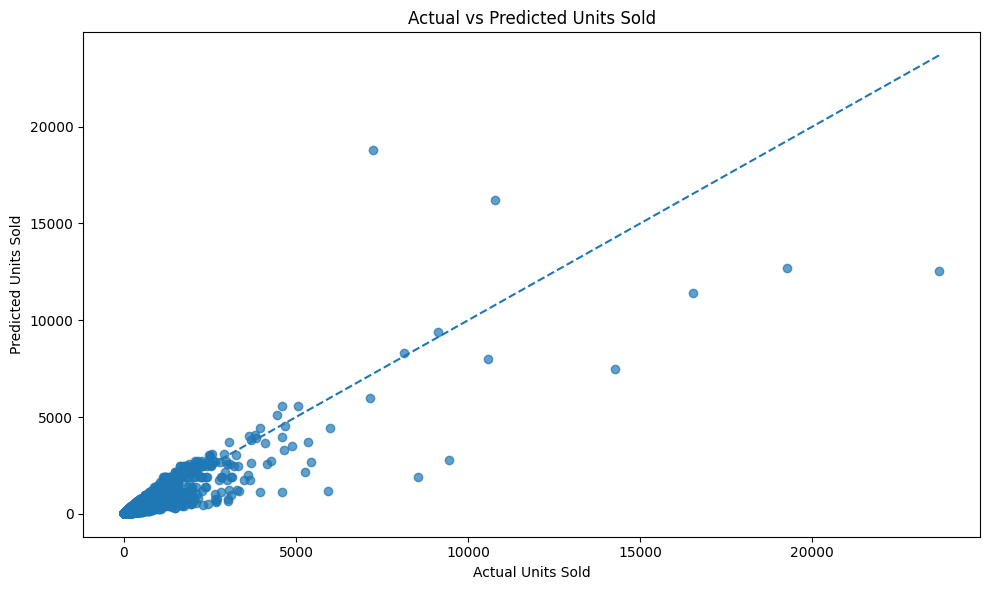

In [36]:
fig = plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)
plt.xlabel('Actual Units Sold')
plt.ylabel('Predicted Units Sold')
plt.title('Actual vs Predicted Units Sold')
show_fig()